In [11]:
import os
# Tải và cài đặt thực thể Graphviz bằng lệnh conda/pip đặc biệt thông qua thư viện hỗ trợ
!pip install graphviz-binary

ERROR: Could not find a version that satisfies the requirement graphviz-binary (from versions: none)
ERROR: No matching distribution found for graphviz-binary

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- 5 dòng dữ liệu đầu tiên ---
  status_account  month_duration  \
0         < 0 DM               6   
1  0 to < 200 DM              48   

                                      credit_history           purpose  \
0  critical account/ other credits existing (not ...  radio/television   
1           existing credits paid back duly till now  radio/television   

   credit_amount               status_savings years_employment  \
0           1169  unknown/ no savings account       >= 7 years   
1           5951                     < 100 DM   1 to < 4 years   

   payment_to_income_ratio                       status_and_sex  \
0                        4                        male : single   
1                        2  female : divorced/separated/married   

  secondary_obligor  ...  collateral age  other_installment_plans housing  \
0              none  ...        none  67                     none     own   
1              none  ...        none  22                     none     own   

  n


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Laptop K1\AppData\Local\Temp\ipykernel_2168\939158373.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



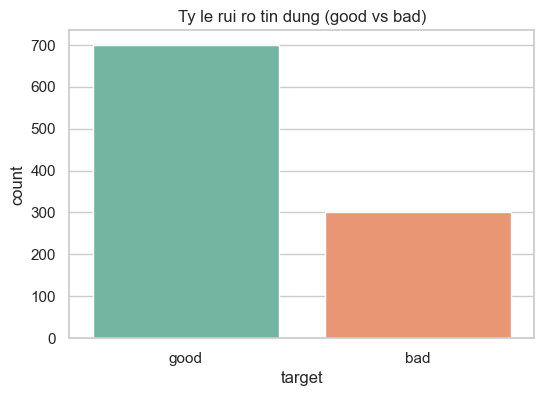


=== KẾT QUẢ MÔ HÌNH 1: LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       140
           1       0.65      0.58      0.61        60

    accuracy                           0.78       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.77      0.78      0.78       200


=== KẾT QUẢ MÔ HÌNH 2: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       140
           1       0.71      0.40      0.51        60

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200


=== KẾT QUẢ MÔ HÌNH 3: DECISION TREE ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76       140
           1       0.47      0.57      0.52        60

    accuracy                           0.68       

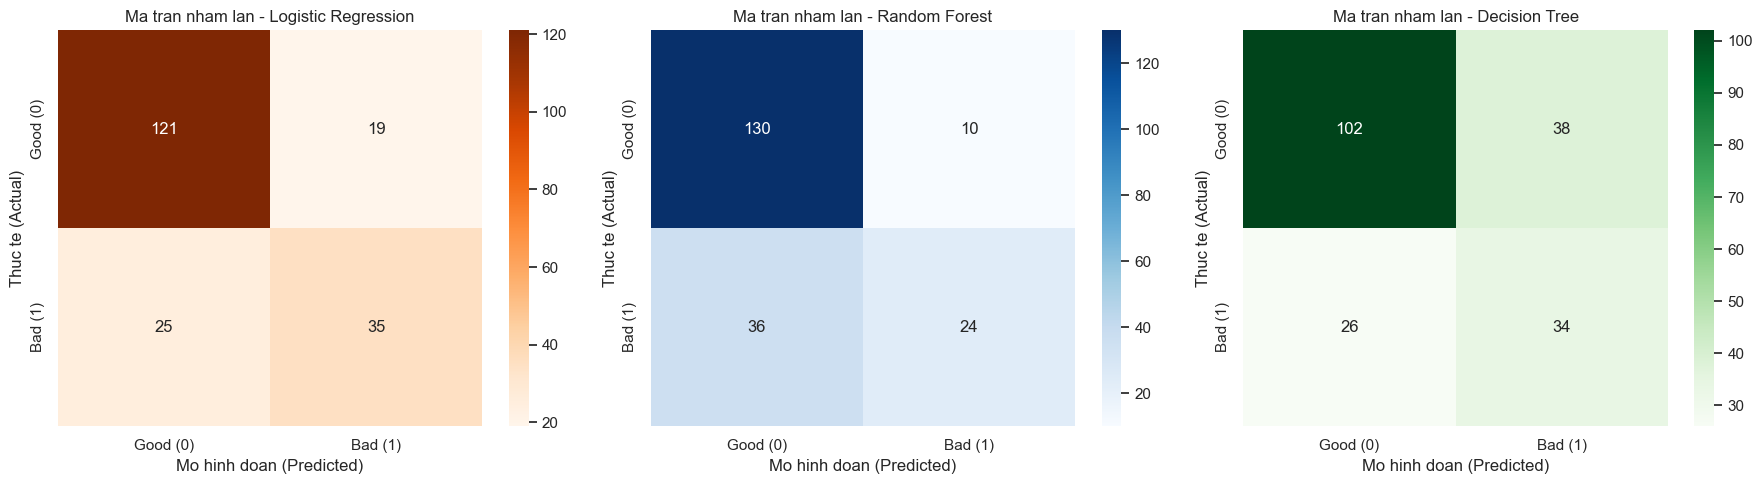

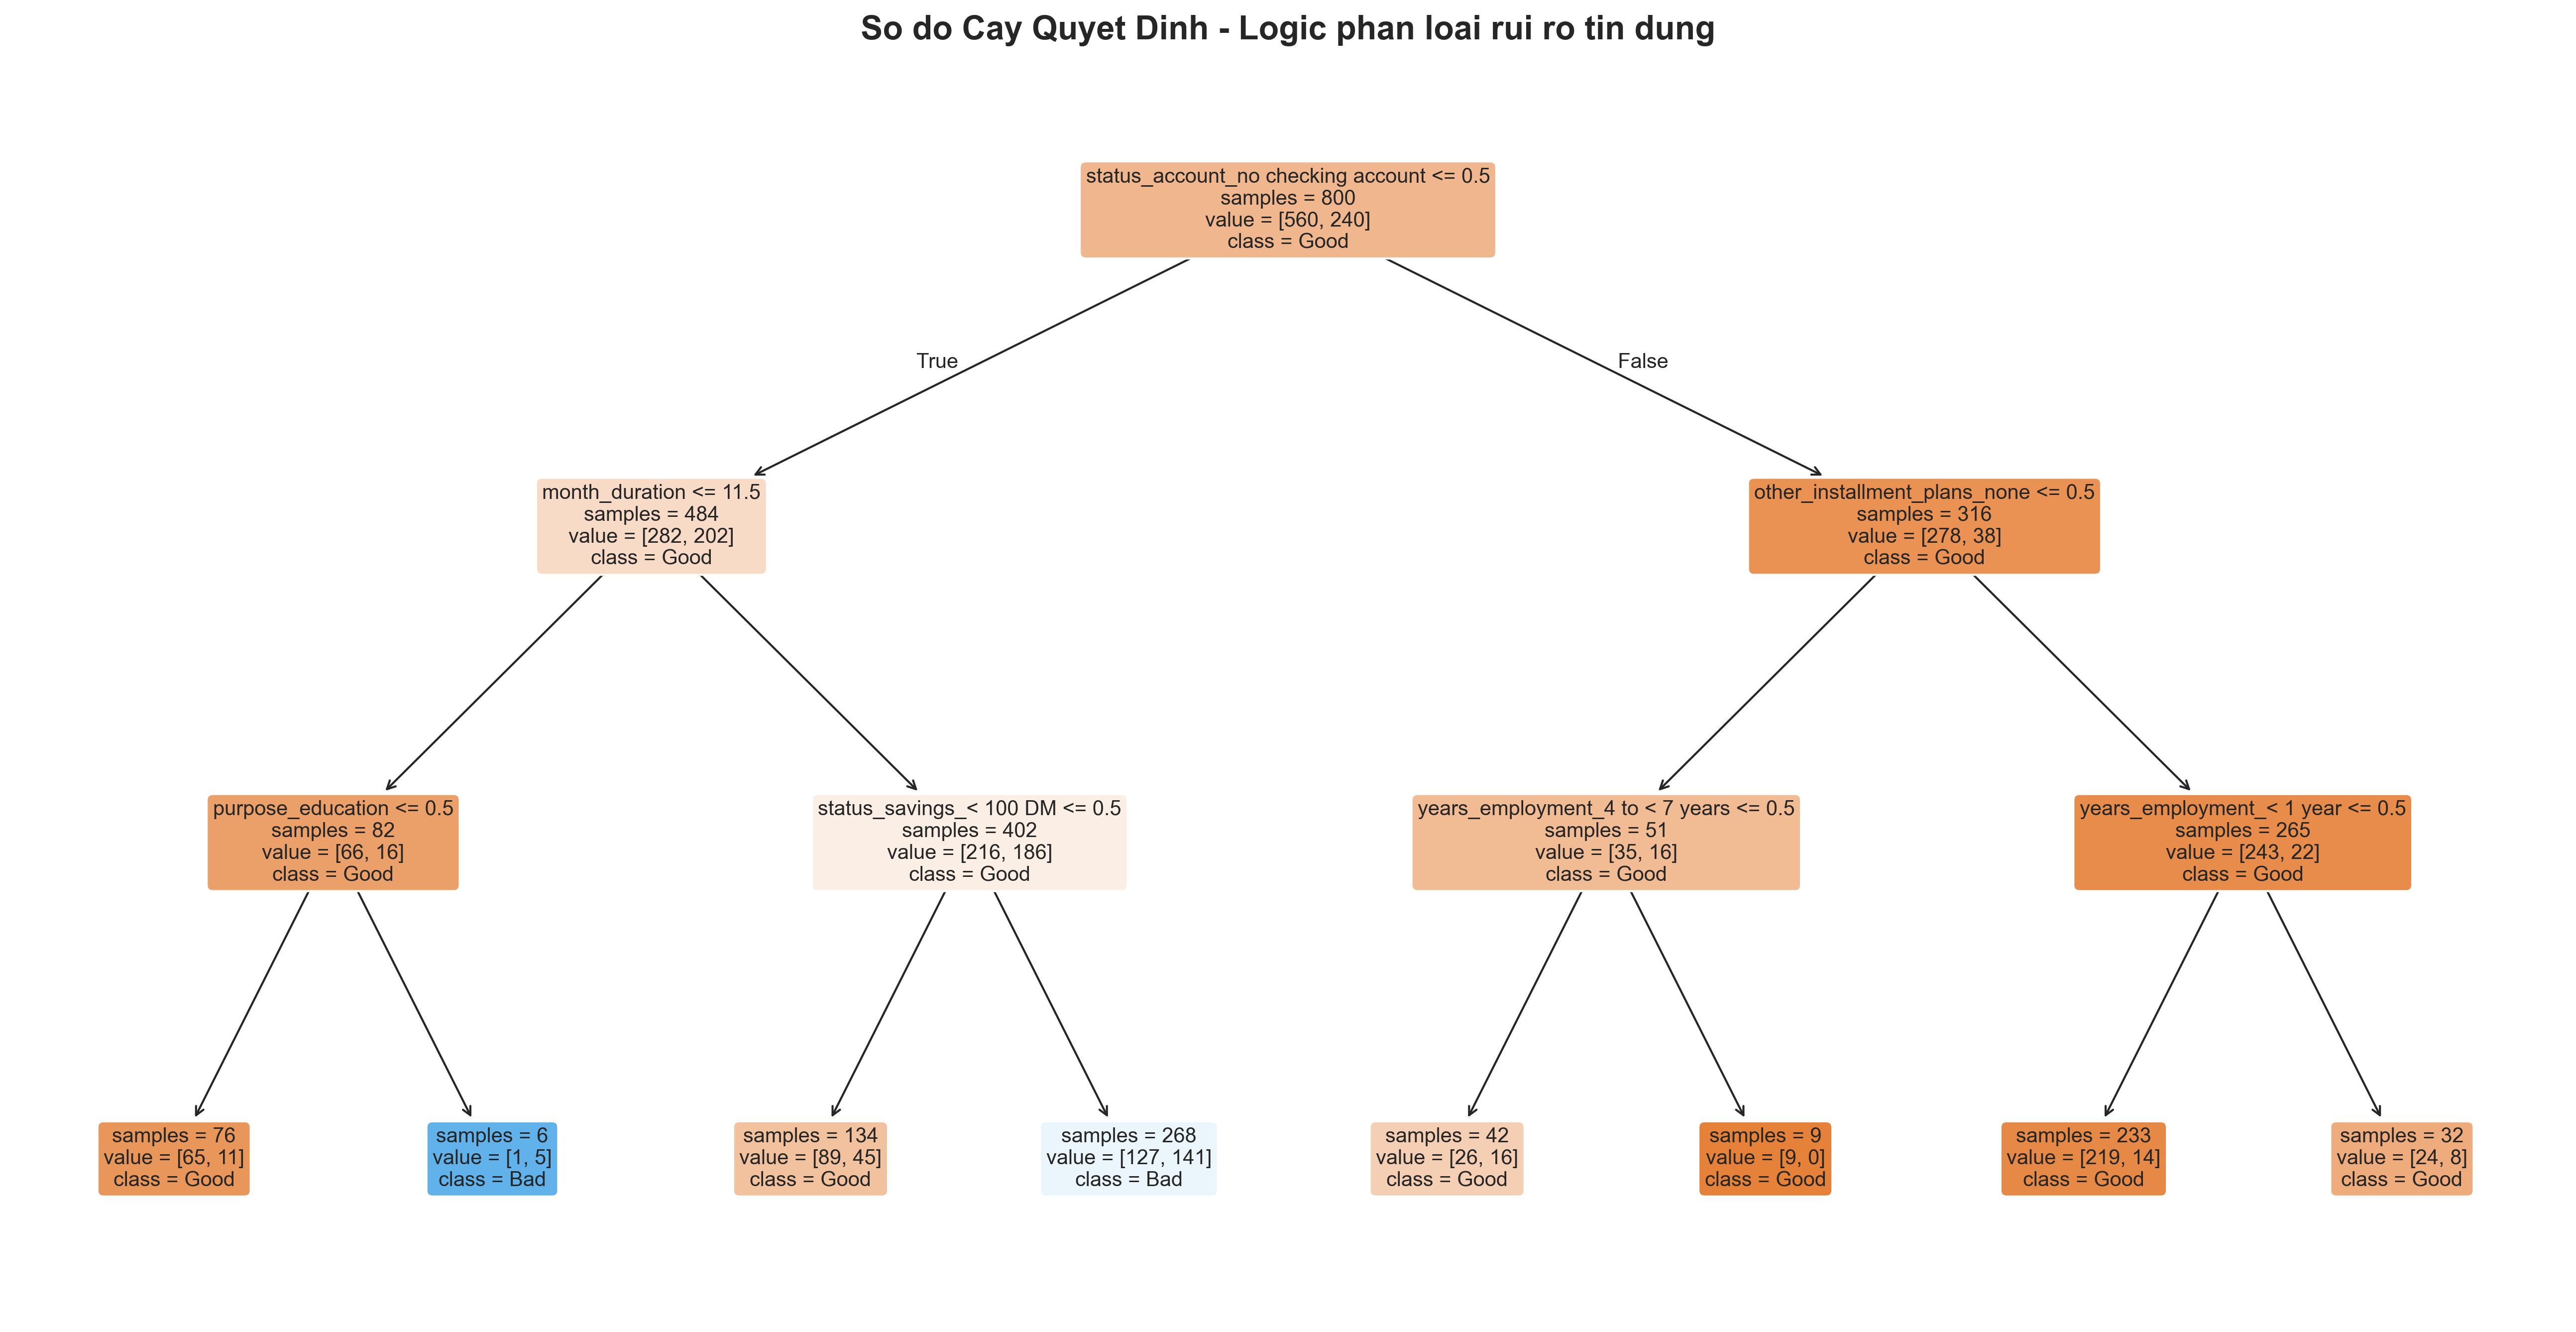


[Thông báo] Đã lưu file ảnh 'cay_quyet_dinh_sach_se.png' thành công!


In [ ]:
# Cài đặt thư viện xử lý mất cân bằng dữ liệu (Chạy 1 lần đầu nếu chưa cài)
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE  # Khai báo thư viện SMOTE nâng cao

# ==========================================
# 1. ĐỌC VÀ KHÁM PHÁ DỮ LIỆU (EDA)
# ==========================================
# Đọc file dữ liệu
df = pd.read_csv('german_credit_data.csv') 

print("--- 5 dòng dữ liệu đầu tiên ---")
print(df.head(2))

# Vẽ biểu đồ kiểm tra tỷ lệ rủi ro bằng cột đúng: 'target'
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Ty le rui ro tin dung (good vs bad)')
plt.show()


# ==========================================
# 2. TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)
# ==========================================
# Tách biến độc lập X và biến mục tiêu y (cột target)
X = df.drop(columns=['target'])

# Chuyển đổi nhãn chữ ('good': 0, 'bad': 1) để mô hình tính toán được
y = df['target'].map({'good': 0, 'bad': 1})

# Chuyển đổi tất cả các cột dạng chữ khác thành dạng số (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Chia tập dữ liệu: 80% để học (Train), 20% để kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuẩn hóa số liệu (Scaling) cho Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 3. XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU BẰNG SMOTE
# ==========================================
print("\n=== XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU ===")
print("Số lượng nhãn tập Train ban đầu:")
print(y_train.value_counts())

# Áp dụng SMOTE để sinh thêm dữ liệu mẫu cho nhóm thiểu số (Bad) cân bằng với nhóm (Good)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Tập dữ liệu chuẩn hóa cũng cần làm cân bằng để phục vụ riêng cho Logistic Regression
X_train_scaled_resampled, y_train_scaled_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nSố lượng nhãn tập Train sau khi xử lý SMOTE (Cân bằng 50/50):")
print(y_train_resampled.value_counts())


# ==========================================
# 4. HUẤN LUYỆN CÁC MÔ HÌNH CƠ BẢN
# ==========================================

# --- Mô hình 1: Logistic Regression ---
log_model = LogisticRegression(random_state=42, max_iter=1000)
# Huấn luyện trên tập dữ liệu đã được scale và làm cân bằng bằng SMOTE
log_model.fit(X_train_scaled_resampled, y_train_scaled_resampled)
y_pred_log = log_model.predict(X_test_scaled)

# --- Mô hình 2: Random Forest (Bản gốc ban đầu) ---
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train) # Giữ nguyên tập train gốc để tí đối chiếu so sánh
y_pred_rf = rf_model.predict(X_test)

# --- Mô hình 3: Decision Tree (Cây quyết định) ---
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


# ==========================================
# 5. TỐI ƯU HÓA THAM SỐ (HYPERPARAMETER TUNING) CHO RANDOM FOREST
# ==========================================
print("\n=== ĐANG CHẠY GRIDSEARCHCV ĐỂ TÌM THAM SỐ TỐI ƯU... ===")

# Thiết lập không gian tìm kiếm các tổ hợp tham số tốt nhất
param_grid = {
    'n_estimators': [50, 100, 200],       # Số lượng cây trong rừng
    'max_depth': [3, 5, 7, None],          # Chiều sâu tối đa để kiểm soát overfitting
    'min_samples_split': [2, 5, 10],       # Số mẫu tối thiểu để phân tách nút
    'criterion': ['gini', 'entropy']       # Phương pháp đo lường chất lượng phân tách
}

rf_base = RandomForestClassifier(random_state=42)

# Tìm cấu hình tối ưu nhất dựa trên việc tối đa hóa chỉ số F1-score trên tập SMOTE
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

print("\n[Kết quả] Bộ tham số tối ưu nhất tìm được:")
print(grid_search.best_params_)

# Trích xuất mô hình hoàn hảo nhất sau khi dò tham số
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)


# ==========================================
# 6. IN BÁO CÁO KẾT QUẢ ĐÁNH GIÁ (CLASSIFICATION REPORT)
# ==========================================
print("\n=== KẾT QUẢ MÔ HÌNH 1: LOGISTIC REGRESSION (ĐÃ DÙNG SMOTE) ===")
print(classification_report(y_test, y_pred_log))

print("\n=== KẾT QUẢ MÔ HÌNH 2: RANDOM FOREST GỐC (CHƯA CAN THIỆP) ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== KẾT QUẢ MÔ HÌNH 2 NÂNG CAO: RANDOM FOREST (SMOTE + GRIDSEARCHCV) ===")
print(classification_report(y_test, y_pred_best_rf))

print("\n=== KẾT QUẢ MÔ HÌNH 3: DECISION TREE GỐC ===")
print(classification_report(y_test, y_pred_dt))


# ==========================================
# 7. TRỰC QUAN HÓA MA TRẬN NHẦM LẪN & VẼ CÂY QUYẾT ĐỊNH
# ==========================================

# 7.1 Vẽ ma trận nhầm lẫn đối chiếu của cả 4 phiên bản mô hình lên màn hình
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Heatmap Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Good (0)', 'Bad (1)'], yticklabels=['Good (0)', 'Bad (1)'])
axes[0].set_title('Logistic Regression\n(With SMOTE)')
axes[0].set_ylabel('Thuc te (Actual)')
axes[0].set_xlabel('Mo hinh doan (Predicted)')

# Heatmap Random Forest Gốc
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Good (0)', 'Bad (1)'], yticklabels=['Good (0)', 'Bad (1)'])
axes[1].set_title('Random Forest\n(Gốc ban đầu)')
axes[1].set_ylabel('Thuc te (Actual)')
axes[1].set_xlabel('Mo hinh doan (Predicted)')

# Heatmap Random Forest Nâng cao
sns.heatmap(confusion_matrix(y_test, y_pred_best_rf), annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['Good (0)', 'Bad (1)'], yticklabels=['Good (0)', 'Bad (1)'])
axes[2].set_title('Random Forest Nâng Cao\n(SMOTE + Tuning)')
axes[2].set_ylabel('Thuc te (Actual)')
axes[2].set_xlabel('Mo hinh doan (Predicted)')

# Heatmap Decision Tree
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[3],
            xticklabels=['Good (0)', 'Bad (1)'], yticklabels=['Good (0)', 'Bad (1)'])
axes[3].set_title('Decision Tree\n(Cây quyết định)')
axes[3].set_ylabel('Thuc te (Actual)')
axes[3].set_xlabel('Mo hinh doan (Predicted)')

plt.tight_layout()
plt.show()


# 7.2 Vẽ cây quyết định phiên bản tối giản sạch sẽ, không dính chữ 'gini'
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 11), dpi=300) 

plot_tree(dt_model, 
          feature_names=list(X.columns), 
          class_names=['Good', 'Bad'], 
          filled=True, 
          rounded=True, 
          impurity=False,    # Ẩn hoàn toàn chữ 'gini'
          proportion=False,  # Ẩn tỷ lệ phần trăm chênh lệch rườm rà
          fontsize=10)       

plt.title("So do Cay Quyet Dinh - Logic phan loai rui ro tin dung", fontsize=16, fontweight='bold')

# Tự động tải và lưu thành file ảnh 'cay_quyet_dinh_sach_se.png' vào thư mục máy tính
plt.savefig('cay_quyet_dinh_sach_se.png', bbox_inches='tight')
plt.show()

print("\n[Thông báo] Đã lưu file ảnh 'cay_quyet_dinh_sach_se.png' thành công!")

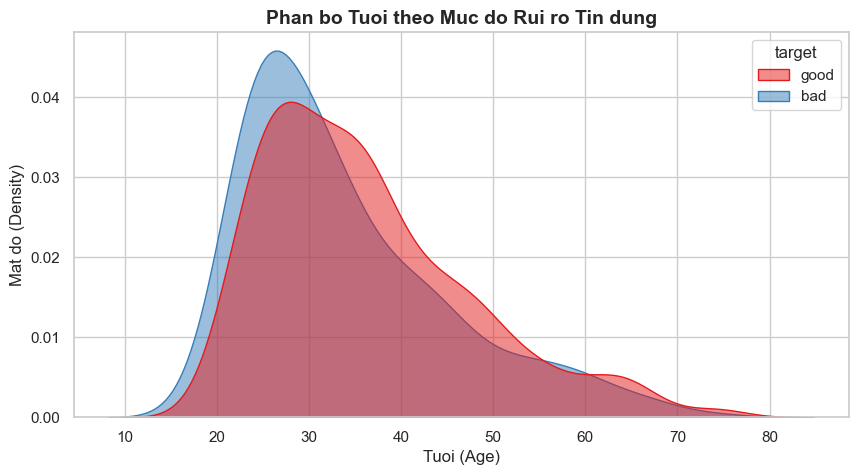

C:\Users\Laptop K1\AppData\Local\Temp\ipykernel_2168\676629685.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='credit_amount', palette='Set2')


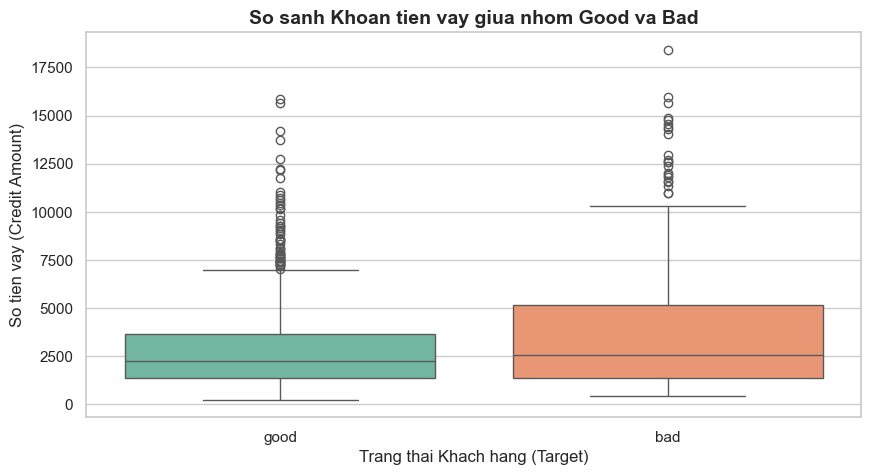

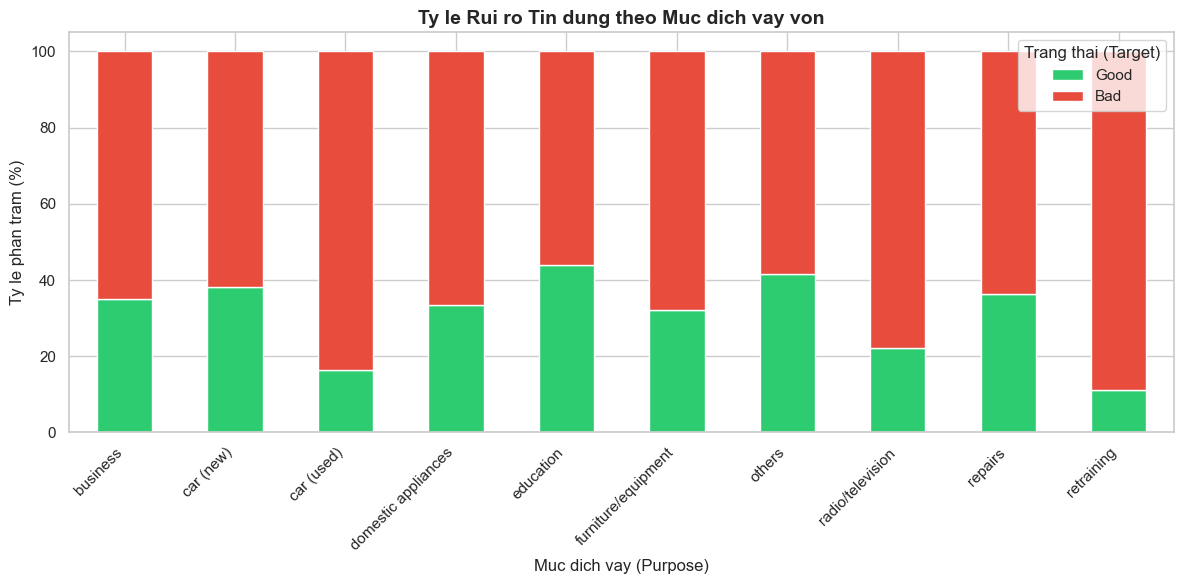

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế giao diện biểu đồ cho đẹp và đồng nhất
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# =====================================================================
# BIỂU ĐỒ 1: Mối quan hệ giữa Tuổi (age) và Rủi ro (target)
# Sử dụng KDE Plot để thấy mật độ phân bố tuổi của nhóm Good vs Bad
# =====================================================================
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='age', hue='target', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Phan bo Tuoi theo Muc do Rui ro Tin dung', fontsize=14, fontweight='bold')
plt.xlabel('Tuoi (Age)', fontsize=12)
plt.ylabel('Mat do (Density)', fontsize=12)
plt.show()

# =====================================================================
# BIỂU ĐỒ 2: Mối quan hệ giữa Số tiền vay (credit_amount) và Rủi ro (target)
# Sử dụng Boxplot để xem dải số tiền vay của nhóm Bad có lớn hơn Good không
# =====================================================================
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target', y='credit_amount', palette='Set2')
plt.title('So sanh Khoan tien vay giua nhom Good va Bad', fontsize=14, fontweight='bold')
plt.xlabel('Trang thai Khach hang (Target)', fontsize=12)
plt.ylabel('So tien vay (Credit Amount)', fontsize=12)
plt.show()

# =====================================================================
# BIỂU ĐỒ 3: Mục đích vay (purpose) ảnh hưởng thế nào đến Rủi ro (target)
# Biểu đồ cột chồng (Stacked Bar Chart) hiển thị tỷ lệ % Bad của từng mục đích
# =====================================================================
# Tính toán tỷ lệ phần trăm chênh lệch
purpose_target = pd.crosstab(df['purpose'], df['target'], normalize='index') * 100

# Vẽ biểu đồ cột chồng
purpose_target.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(12, 6))
plt.title('Ty le Rui ro Tin dung theo Muc dich vay von', fontsize=14, fontweight='bold')
plt.xlabel('Muc dich vay (Purpose)', fontsize=12)
plt.ylabel('Ty le phan tram (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trang thai (Target)', labels=['Good', 'Bad'])
plt.tight_layout()
plt.show()